# <Font color = 'indianred'>**Sentiment Analysis using Hugging Face Ecosystem** </font>

**Objective**: We will now enhance our sentiment analysis notebook for IMDb dataset by adopting the Hugging Face ecosystem. Hugging Face ecosystem provides a range of efficient tools and utilities that complement PyTorch's flexibility, facilitating easier implementation of NLP tasks. We will make the following changes

1. **Model Adaptation**: We'll tweak our model class for compatibility with the Hugging Face ecosystem.

2. **Streamlined Data Handling**: We will use Hugging Face Datasets library to load and preprocess the IMDb dataset , This will eliminate the need for creating custom dataset class. We will still need to create Vocab and collate function.

3. **Eliminate Training Loops**: We will use Hugging Face Trainer to handle the training process automatically. This will eliminate the need for creating our own custom functions for training loops.

4. **Efficient Model Management**: The Trainer also simplifies saving and loading models, with features like tracking and saving the 'Best Model'. Unlike our previous method of evaluating after every epoch, the Trainer offers the flexibility to evaluate and save model at various intervals.

5. **Better integration of evaluation metrics**: In the previous notebook, incorporating additional metrics like accuracy (for model evaluation during training) required manual code changes. We will now use **evaluate library**, that will help us to  seamlessly include various metrics, and the Trainer automatically computes them during the evaluation phase. This setup significantly simplifies the process of model performance assessment and comparison, making it more flexible and less error-prone.

6. **Enhanced Experiment Tracking**: We will also incorporate Weights & Biases (WandB) for robust experiment tracking, enabling real-time logging of training metrics, hyperparameters, and outputs, making it much easier to compare different models and runs.

**Plan**:
1. Set Environment: Load libraries needed and specify folders for saving dataset and model.
2. Load Data: Load the moview review data from files provided.
3. Create Huggingface Dataset
4. Create Custom Model and Model Config Class
5. Train Model
  1. Collate Function <br>
  2. Instantiate Model <br>
  3. Compute Metric Function <br>
  4. Training Arguments <br>
  5. Instantiate Trainer <br>
  6. Setup WandB <br>
  7. Training and Validation
6. Perfromance on Test Set
7. Model Inference

<br>

**Previous Workflow**

<img src ="https://drive.google.com/uc?export=view&id=1GShf7FdfqkmedOFINDsQTwDF2Txj2dDv" width =800>


<br><br>

**Revised Workflow**

<img src ="https://drive.google.com/uc?export=view&id=1Q9F-oqg69v_fLOv5vK6LV5pPMatEg43Z" width =500>

## <Font color = 'indianred'>**1. Set Environment**

In this notebook, we have to install following additional libraries (compared to previous notebooks) from Huggingface  to enhance our workflow: **transformers**, **datasets**, **evaluate**, and **accelearte**. In addition, we are also installing **wandb**.

- The transformers library provides **Trainer** class that we will use to manage Training process.
- The **datasets** library simplifies the process of accessing and manipulating a wide array of datasets.
- The **evaluate** library offers a suite of standardized metrics and methods for robust and consistent model evaluation.
- We will not use **accelerate** library directly. However , we need to install it as transformer librray usses it in the background.
- Finally **wandb** library provide tools for efficient experiment tracking.

In [ ]:


!pip uninstall -y tensorflow opencv-python opencv-python-headless cupy numba
!pip install --upgrade \
    numpy==1.26.5 \
    torch==2.3.1+cu121 torchvision==0.17.1+cu121 torchaudio==2.3.2+cu121 \
    torchtext==0.17.1 \
    transformers==4.42.2 \
    datasets==2.15.0 \
    evaluate==0.4.0 \
    wandb==1.44.0 \
    accelerate==0.23.0 \
    scikit-learn==1.3.2 \
    -f https://download.pytorch.org/whl/torch_stable.html


Looking in links: https://download.pytorch.org/whl/torch_stable.html
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.26.5 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0,

In [ ]:
!pip install evaluate


 <Font size = 5 color = 'indianred'>**Restart the session before moving onto next cell**
> Runtime- Restart Session

In [ ]:
# Importing PyTorch library for tensor computations and neural network modules
import torch
import torch.nn as nn

# For working with textual data vocabularies and for displaying model summaries
import os
# General-purpose Python libraries for random number generation and numerical operations
import random
import numpy as np

# Utilities for efficient serialization/deserialization of Python objects and for element tallying
import joblib
from collections import Counter

# For creating lightweight attribute classes and for partial function application
from functools import partial

# For filesystem path handling, generating and displaying confusion matrices, and date-time manipulations
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, hamming_loss
from datetime import datetime
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# For plotting and visualization
import matplotlib.pyplot as plt
import seaborn as sns
# %matplotlib inline

### NEW ##########################
# imports from Huggingface ecosystem
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers import PreTrainedModel, PretrainedConfig
from transformers import TrainingArguments, Trainer
from datasets import Dataset as HFDataset
from torch.nn.utils import clip_grad_value_
import evaluate

# wandb library
import wandb
from google.colab import userdata
from huggingface_hub import login

In [ ]:
from html import unescape
import re


- `from transformers.modeling_outputs import SequenceClassifierOutput`: This import provides a specific output format for sequence classification tasks required by Huggingface Trainer. We will use this in our custom model.
- `from transformers import PreTrainedModel, PretrainedConfig`: All models should be subclass of `PreTrainedModel` for the model to work with Trainer. We will also need to create a config file for the model which should be subclass of `PretrainedConfig.`
- `from transformers import TrainingArguments, Trainer`: `TrainingArguments` is used to define training hyperparameters, while `Trainer` is a high-level API for training, fine-tuning, and evaluating models easily.
- `from datasets import Dataset`: This import from the `datasets` library is used to handle datasets more efficiently.
- `import evaluate`: This import brings in the `evaluate` library that offers various metrics to assess the performance of NLP models.
`import wandb`: This import integrates the Weights & Biases library, a tool for experiment tracking.



In [ ]:
wandb_api_key = userdata.get('WANDB_API_KEY')
hf_token = userdata.get('HF_TOKEN')

In [ ]:
if hf_token:
    # Log in to Hugging Face
    login(token=hf_token)
    print("Successfully logged in to Hugging Face!")
else:
    print("Hugging Face token not found in notebook secrets.")

Successfully logged in to Hugging Face!


In [ ]:
if wandb_api_key:
  wandb.login(key=wandb_api_key)
  print("Successfully logged in to WANDB!")
else:
    print("WANDB key not found in notebook secrets.")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Successfully logged in to WANDB!


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
EMBED_DIM = 300
HIDDEN1 = 200
HIDDEN2 = 100
EPOCHS = 10
BATCH_SIZE = 128
LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.01
DROP_PROB1 = 0.5
DROP_PROB2 = 0.5
CLIP_VALUE = 10.0
CLIP_NORM_DISABLED=10000.0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "./hf_trainer_results"
METRIC_FOR_BEST_MODEL = "f1_macro"
MIN_FREQ = 2

In [ ]:
import pandas as pd

train_df_full = pd.read_csv('/content/drive/My Drive/emotion-detection-fall-2025-nlp/train.csv')
test_df_full= pd.read_csv('/content/drive/My Drive/emotion-detection-fall-2025-nlp/test.csv')


In [ ]:
TEXT_COL = "Tweet"
ID_COL = "ID"
label_cols = [c for c in train_df_full.columns if c not in (TEXT_COL, ID_COL)]
output_dim=len(label_cols)

In [ ]:
def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    text = unescape(text)
    text = text.replace('\n', ' ')

    text = re.sub(r'http\S+|www\.\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = text.replace('â€œ', '"').replace('â€™', "'").replace('ðŸ', '')

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
train_df_full[TEXT_COL] = train_df_full[TEXT_COL].astype(str).apply(clean_tweet).str.lower()

test_df_full[TEXT_COL] = test_df_full[TEXT_COL].astype(str).apply(clean_tweet).str.lower()


In [ ]:

train_val_df, test_df_internal = train_test_split(
    train_df_full,
    test_size=0.15,
    random_state=SEED,
    shuffle=True
)


train_df_final, val_df_final = train_test_split(
    train_val_df,
    test_size=(0.15 / 0.85),
    random_state=SEED,
    shuffle=True
)


In [ ]:
train_texts = train_df_final[TEXT_COL].values
train_labels = train_df_final[label_cols].values

val_texts = val_df_final[TEXT_COL].values
val_labels = val_df_final[label_cols].values

test_texts_internal = test_df_internal[TEXT_COL].values
test_labels_internal = test_df_internal[label_cols].values

print(f"Total Samples: {len(train_df_full)}")
print(f"Train Samples: {len(train_texts)} ({len(train_texts)/len(train_df_full):.2%})")
print(f"Validation Samples: {len(val_texts)} ({len(val_texts)/len(train_df_full):.2%})")
print(f"Internal Test Samples: {len(test_texts_internal)} ({len(test_texts_internal)/len(train_df_full):.2%})")


Total Samples: 7724
Train Samples: 5406 (69.99%)
Validation Samples: 1159 (15.01%)
Internal Test Samples: 1159 (15.01%)


In [ ]:
def build_vocab(texts, min_freq=MIN_FREQ):
    counter = Counter()
    for t in texts: counter.update(t.split())
    tokens = [tok for tok, cnt in counter.items() if cnt >= min_freq]
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for i, tok in enumerate(tokens, start=2): vocab[tok] = i
    return vocab

In [ ]:
vocab = build_vocab(train_texts)
vocab_size = len(vocab)
print(f"Vocabulary size after min_freq={MIN_FREQ}: {vocab_size}")

Vocabulary size after min_freq=2: 6351


In [ ]:
def encode_text(text, vocab):

    return [vocab.get(tok, vocab["<UNK>"]) for tok in text.split()]

In [ ]:
def prepare_hf_dataset(texts, labels=None):
    data = {"text": texts}
    if labels is not None:

        data["labels"] = labels.tolist()

    hf_dataset = HFDataset.from_dict(data)

    def tokenize_and_encode(examples):
        encoded_texts = [encode_text(t, vocab) for t in examples["text"]]
        return {"input_ids": [torch.tensor(t, dtype=torch.long) for t in encoded_texts]}

    tokenized_dataset = hf_dataset.map(
        tokenize_and_encode,
        batched=True,
        remove_columns=["text"],
        load_from_cache_file=False
    )

    if labels is not None:

        tokenized_dataset.set_format("torch", columns=["input_ids", "labels"], output_all_columns=True)
    else:
        tokenized_dataset.set_format("torch", columns=["input_ids"], output_all_columns=True)

    return tokenized_dataset

In [ ]:
train_hf_dataset = prepare_hf_dataset(train_texts, train_labels)

val_hf_dataset = prepare_hf_dataset(val_texts, val_labels)

test_hf_dataset_internal = prepare_hf_dataset(test_texts_internal, test_labels_internal)


Map:   0%|          | 0/5406 [00:00<?, ? examples/s]

Map:   0%|          | 0/1159 [00:00<?, ? examples/s]

Map:   0%|          | 0/1159 [00:00<?, ? examples/s]

## <Font color = 'indianred'>**4. Create Custom Model and Model Config Class** </font>
embedding_layer-->linear--> ReLU -->dropout --> batch norm --> linear-->ReLu-->Dropout--> batchnorm ---> linear layer

The new `CustomMLP` model represents a significant adaptation to align with the conventions of the Hugging Face ecosystem, which differs from traditional PyTorch models in several key ways:

### High-Level Changes for Hugging Face Compatibility:

1. **Output of Both Loss and Logits**:
   - In the Hugging Face framework, models typically output both the loss and the logits, as opposed to traditional models which might only output logits.

2. **Requirement of a Configuration Class**:
   - Hugging Face models rely on a configuration class, like `CustomConfig`, to handle various model settings and hyperparameters. This configuration class is essential for defining model-specific parameters and ensures that the model can be easily adjusted, saved, and loaded with these configurations.

3. **Inheritance from `PreTrainedModel`**:
   - Models in the Hugging Face ecosystem are typically subclasses of `PreTrainedModel` rather than the standard `nn.Module` used in PyTorch. This subclassing provides additional functionalities crucial for Hugging Face models, such as compatibility with pre-trained weights, standardized methods for loading/saving models, and integration with the rest of the Hugging Face libraries.

In [ ]:
class CustomConfig(PretrainedConfig):
    model_type = "custom_mlp"
    attribute_map = {"hidden_size": "embedding_dim", "num_labels": "num_labels"}
    def __init__(self, vocab_size=50000, embedding_dim=EMBED_DIM, hidden_dim1=HIDDEN1,
                 hidden_dim2=HIDDEN2, num_labels=output_dim, drop_prob1=DROP_PROB1, drop_prob2=DROP_PROB2, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim1 = hidden_dim1
        self.hidden_dim2 = hidden_dim2
        self.num_labels = num_labels
        self.drop_prob1 = drop_prob1
        self.drop_prob2 = drop_prob2

* `**kwargs` allows the class to accept any additional configuration attributes that are not part of the standard set of attributes defined in the class, providing flexibility and extensibility.

In [ ]:
class CustomMLP(PreTrainedModel):
    config_class = CustomConfig

    def __init__(self, config):
        super().__init__(config)
        self.config = config

        self.embedding_bag = nn.EmbeddingBag(config.vocab_size, config.embedding_dim, mode='mean', sparse=False)

        self.layers = nn.Sequential(

            nn.Linear(config.embedding_dim, config.hidden_dim1),
            nn.ReLU(),
            nn.Dropout(p=config.drop_prob1),
            nn.BatchNorm1d(num_features=config.hidden_dim1),


            nn.Linear(config.hidden_dim1, config.hidden_dim2),
            nn.ReLU(),
            nn.Dropout(p=config.drop_prob2),
            nn.BatchNorm1d(num_features=config.hidden_dim2),


            nn.Linear(config.hidden_dim2, config.num_labels)
        )


    def forward(self, input_ids, offsets, labels=None, **kwargs):
        embed_out = self.embedding_bag(input_ids, offsets)

        if embed_out.dim() == 1:
            embed_out = embed_out.unsqueeze(0)

        logits = self.layers(embed_out)

        loss = None
        if labels is not None:
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits
        )


config = CustomConfig(vocab_size=vocab_size, embedding_dim=EMBED_DIM, hidden_dim1=HIDDEN1,
                      hidden_dim2=HIDDEN2, num_labels=output_dim, drop_prob1=DROP_PROB1, drop_prob2=DROP_PROB2)
model = CustomMLP(config).to(DEVICE)


In [ ]:
class CustomDataCollator:
    """
    Correct offsets computation for EmbeddingBag when batching tokenized inputs.
    Expects each batch item to have 'input_ids' as a 1-D torch tensor.
    """
    def __call__(self, batch):
        texts = [item["input_ids"] for item in batch]

        labels = None
        if "labels" in batch[0]:
            labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])

        # lengths of each sequence (number of token indices)
        lengths = [t.size(0) for t in texts]
        # offsets: starting index of each example in the concatenated tensor
        offsets = [0] + np.cumsum(lengths[:-1]).tolist()
        offsets = torch.tensor(offsets, dtype=torch.long)

        # concatenate input ids for EmbeddingBag
        input_ids_cat = torch.cat([t.to(torch.long) for t in texts], dim=0)

        model_inputs = {
            "input_ids": input_ids_cat,
            "offsets": offsets,
        }
        if labels is not None:
            model_inputs["labels"] = labels

        return model_inputs


data_collator = CustomDataCollator()

*`CustomConfig` Class*:
- `CustomConfig` class which inherits from `PretrainedConfig is used to define essential parameters such as `vocab_size`, `embedding_dim`, hidden dimensions, and `num_labels`. These parameters are critical for specifying the model's architecture.

*Model Structure:*
- Inherits from `PreTrainedModel`, aligning it with the Hugging Face model architecture requirements.
- The `config_class` attribute is set to `CustomConfig`, establishing the link between the model and its configuration.

*Model Components:*
- *Embedding Layer*: Utilizes `nn.EmbeddingBag` for efficient embedding of input text, configured with `vocab_size` and `embedding_dim` from the model's configuration.
- *Sequential Layers*: The model comprises linear layers, batch normalization, ReLU activation functions, and dropout layers organized in a sequential manner.

*Forward Pass:*
- The `forward` method takes `input_ids`, `offsets`, and an optional `labels` parameter.
- The method computes embeddings using `nn.EmbeddingBag` and passes the result through the sequential layers to produce logits.
- If `labels` are provided, the model calculates the loss using `nn.CrossEntropyLoss`. This is particularly relevant when training the model, as it allows for loss computation within the model itself.

*Output Format:*
- The model outputs a `SequenceClassifierOutput`, a format standard in Hugging Face, containing both the loss (if computed) and logits. This structure is essential for compatibility with various utilities in the Hugging Face ecosystem, including the `Trainer` class.



In [ ]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    h_loss = hamming_loss(labels, preds)

    return {"f1_macro": macro_f1, "hamming_loss": h_loss}

### <font color = 'indianred'> **5.4. Training Arguments**</font>

The `TrainingArguments` class in the Hugging Face Transformers library is a comprehensive configuration tool that defines a wide range of parameters for training machine learning models. The `TrainingArguments` class in Hugging Face is used to configure three key aspects of training machine learning models:

1. **Training-specific Configurations**: These settings define the core aspects of the training process. This include parameters like `epochs`, `batch seze` etc.

2. **Evaluation and Checkpoint Settings**: This group includes parameters for saving model checkpoints and evaluating the model's performance during training.

3. **Experiment Logging Configurations**: These settings are related to logging and tracking the training process.

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    optim="adamw_torch",
    lr_scheduler_type="constant",
    warmup_ratio=0.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model=METRIC_FOR_BEST_MODEL,
    greater_is_better=True,
    seed=SEED,
    logging_strategy="epoch",
    save_total_limit=2,
    dataloader_num_workers=2,
    max_grad_norm=10.0,
    report_to="none"
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf_dataset,

    eval_dataset=val_hf_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)


trainer.train()
print("\nTraining complete. Best model loaded based on 'f1_macro'.")


/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])
/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])


Epoch,Training Loss,Validation Loss,F1 Macro,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.546700,0.480350,0.120806,0.217194,0.204500,5667.879000,48.903000
2,0.434400,0.422188,0.219214,0.185897,0.206300,5617.064000,48.465000
3,0.379300,0.416772,0.235294,0.181426,0.177200,6541.289000,56.439000
4,0.346800,0.410317,0.273980,0.176641,0.182100,6363.042000,54.901000
5,0.323200,0.414112,0.308246,0.174916,0.182400,6355.521000,54.836000
6,0.304000,0.414873,0.316768,0.174680,0.176000,6586.142000,56.826000
7,0.289400,0.437453,0.324086,0.180328,0.176300,6573.922000,56.721000
8,0.274800,0.424044,0.357364,0.172641,0.188600,6145.287000,53.022000
9,0.257700,0.440793,0.360487,0.177269,0.275200,4211.316000,36.336000
10,0.246800,0.454737,0.373915,0.173347,0.181700,6377.467000,55.026000


/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])
/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])
/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])
/tmp/ipython-input-161983


Training complete. Best model loaded based on 'f1_macro'.


In [ ]:
print("Section 5: Final Evaluation on Internal Test Split ")

test_output = trainer.predict(test_hf_dataset_internal)

Section 5: Final Evaluation on Internal Test Split 


/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])
/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])


In [ ]:
print(" Evaluation Metrics on FINAL Internal Test Split ")
for key, value in test_output.metrics.items():

    if key.startswith('test_'):
        print(f"- Internal {key.replace('test_', '')}: {value:.4f}")
    else:
        print(f"- Internal {key}: {value:.4f}")


 Evaluation Metrics on FINAL Internal Test Split 
- Internal loss: 0.4565
- Internal f1_macro: 0.3487
- Internal hamming_loss: 0.1777
- Internal runtime: 0.1834
- Internal samples_per_second: 6318.8000
- Internal steps_per_second: 54.5190


In [ ]:
test_labels = test_output.label_ids
test_preds_logits = test_output.predictions


In [ ]:
test_preds_probs = 1.0 / (1.0 + np.exp(-test_preds_logits))
test_preds_binary = (test_preds_probs >= 0.5).astype(int)

### <Font color = 'indianred'>**5.5.Setup WandB**
Before we start training, we will log into WandB so that we can track our experiment.

In [ ]:
# specify the project name where the experiment will be logged
%env WANDB_PROJECT = nlp_course_fall_2025-sentiment-analysis-hf-trainer

env: WANDB_PROJECT=nlp_course_fall_2025-sentiment-analysis-hf-trainer


###  <font color = 'indianred'> **5.6. Training and Validation**</font>

<font color = 'indianred'> *Evaluate model on Validation Set* </font>

Even though we have been evaluating the model periodically during training (e.g., every few epochs), trainer.evaluate() is typically used to perform a final, comprehensive evaluation after all training epochs are completed. This ensures that you assess the model's performance after it has been fully trained and using the best model. We can use these statistice to compare different experiments with different hyperparameters/models.

In [ ]:
trainer.evaluate()

/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])
/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])


{'eval_loss': 0.4547373950481415,
 'eval_f1_macro': 0.3739151954661766,
 'eval_hamming_loss': 0.17334692917091538,
 'eval_runtime': 0.1871,
 'eval_samples_per_second': 6195.553,
 'eval_steps_per_second': 53.456,
 'epoch': 10.0}

<font color = 'indianred'> *Confusion Matrix*</font>

The metrics, while useful, do not always provide a complete picture of a model's performance. It's important to also examine the confusion matrix to gain insights into the specific types of errors the model is making, such as the frequency of false positives and false negatives. This deeper analysis helps in understanding the model's behavior across different classes and in fine-tuning its performance for more balanced and accurate predictions.

In [ ]:
valid_output = trainer.predict(val_hf_dataset)

/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])
/tmp/ipython-input-1619838481.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.stack([torch.tensor(item["labels"], dtype=torch.float) for item in batch])


In [ ]:
valid_output._fields

('predictions', 'label_ids', 'metrics')

The `valid_output` object returned by the `Trainer` class's `predict` method is structured as `('predictions', 'label_ids', 'metrics')`. `predictions` contain the model's raw logits or scores for each input in the validation set, from which predicted classes are derived. `label_ids` are the true labels for these inputs, essential for comparison and metric computation. `metrics` encompasses additional evaluation measures calculated from the model's predictions and actual labels, as defined in the `compute_metrics` function.

In [ ]:
def plot_confusion_matrix_per_label(true_labels, predicted_binary, class_labels):
    """
    Generates and plots a 2x2 confusion matrix for each individual label
    in a multi-label classification task.
    """
    print(" Generating Confusion Matrices for Each Label ")

    num_labels = len(class_labels)
    cols = 3
    rows = (num_labels + cols - 1) // cols

    plt.figure(figsize=(cols * 6, rows * 5))

    for i, label_name in enumerate(class_labels):
        y_true_label = true_labels[:, i]
        y_pred_label = predicted_binary[:, i]


        cm = confusion_matrix(y_true_label, y_pred_label, labels=[0, 1])


        plt.subplot(rows, cols, i + 1)
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            cbar=False,
            xticklabels=['Not ' + label_name, label_name],
            yticklabels=['Not ' + label_name, label_name]
        )
        plt.title(f'CM for Label: {label_name}', fontsize=14)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)

    plt.suptitle("Confusion Matrix Analysis Per Class (Internal Test Set)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

 Generating Confusion Matrices for Each Label 


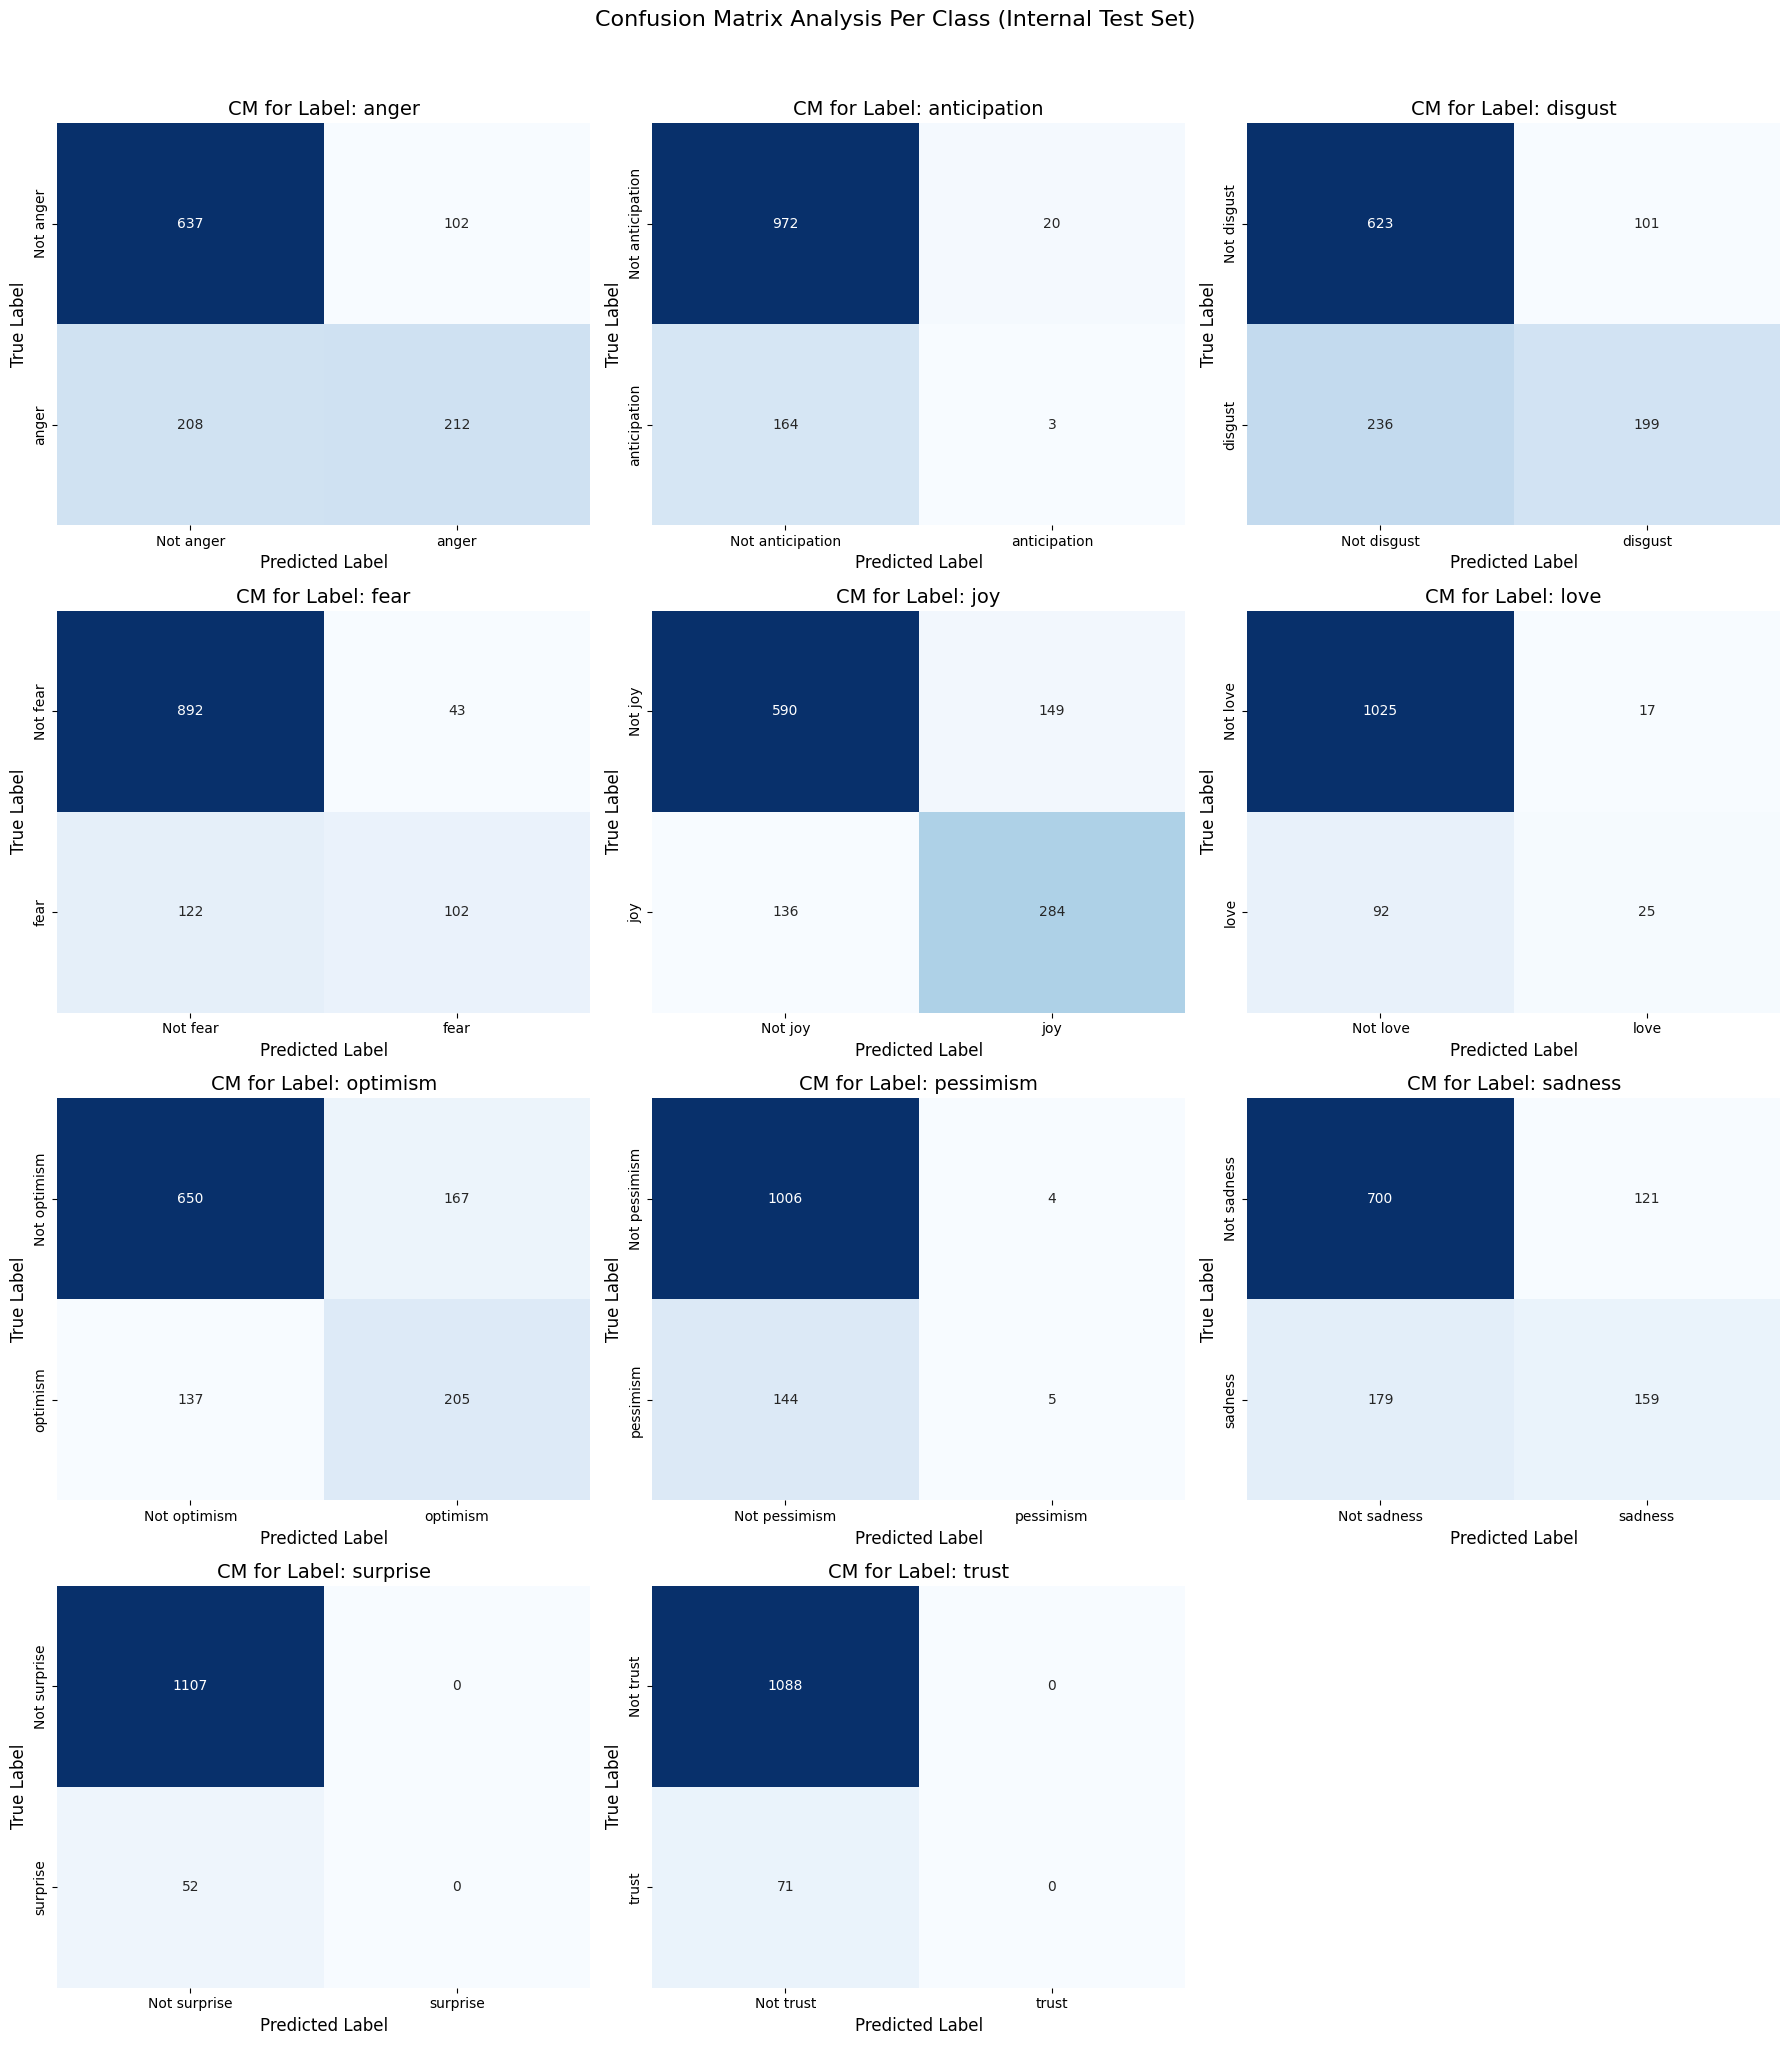

In [ ]:
plot_confusion_matrix_per_label(test_labels, test_preds_binary, class_labels=label_cols)


<font color = 'indianred'> *Get best checkpoint*</font>

In [ ]:
best_model_checkpoint_step = trainer.state.best_model_checkpoint.split('-')[-1]

In [ ]:
wandb.finish()

Analysis


In [ ]:
sample_X = test_texts_internal[0:5]

In [ ]:

import wandb
with wandb.init(mode="disabled"):


    kaggle_texts = test_df_full[TEXT_COL].values

    kaggle_hf_dataset = prepare_hf_dataset(kaggle_texts, labels=None)


    kaggle_predictions_output = trainer.predict(kaggle_hf_dataset)


    kaggle_logits = kaggle_predictions_output.predictions

    kaggle_probs = 1.0 / (1.0 + np.exp(-kaggle_logits))
    kaggle_preds_binary = (kaggle_probs >= 0.5).astype(int)

    submission = pd.DataFrame(kaggle_preds_binary, columns=label_cols)
    submission.insert(0, ID_COL, test_df_full[ID_COL].values)


    submission_path = "hf_submission_kaggle.csv"
    submission.to_csv(submission_path, index=False)

print(f"Kaggle submission file successfully created at: {submission_path}")

Map:   0%|          | 0/3259 [00:00<?, ? examples/s]

Kaggle submission file successfully created at: hf_submission_kaggle.csv


In [ ]:
from google.colab import files
files.download("hf_submission_kaggle.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

*Step 1. Preprocessing*

In [ ]:
sample_X = test_texts_internal[0:5]

In [ ]:
list_of_list_of_indices = [encode_text(text, vocab) for text in sample_X]

# Compute the offsets for each text in the concatenated tensor
offsets_list = [0] + [len(i) for i in list_of_list_of_indices]
# Move to device for model input
offsets = torch.tensor(offsets_list[:-1]).cumsum(dim=0).to(DEVICE)

# Concatenate all text indices into a single tensor
# Move to device for model input
indices = torch.cat([torch.tensor(i, dtype=torch.int64) for i in list_of_list_of_indices]).to(DEVICE)


*Step 2: Get Predictions*

In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(input_ids=indices, offsets=offsets)


In [ ]:
outputs.logits

tensor([[-4.4421, -0.8262, -3.9788, -2.3892,  1.4075, -1.9576,  0.9001, -3.1698,
         -2.0234, -2.1252, -1.7948],
        [-0.3648, -1.5436,  0.0180, -0.6757, -2.7686, -4.7820, -2.4430, -1.3380,
          0.2479, -2.6992, -4.4150],
        [-1.9614, -1.2204, -1.4634, -1.0184, -1.6687, -4.3174, -1.2945, -2.6122,
         -1.3618, -3.3239, -3.8888],
        [ 1.6629, -5.4017,  1.6544, -1.4969, -5.6266, -7.0746, -6.6910, -0.6265,
          3.3633, -4.9627, -8.4945],
        [ 0.0653, -1.5350, -0.1759, -1.9862, -2.0535, -5.0891, -1.8399, -3.0310,
         -1.4345, -3.1264, -4.4182]], device='cuda:0')

*Step 3: Post Processing*

In [ ]:

probs = torch.sigmoid(outputs.logits)


predictions_binary = (probs >= 0.5).int()


predicted_labels = []
for instance_preds in predictions_binary.cpu().numpy():
    true_labels = [label_cols[i] for i, pred in enumerate(instance_preds) if pred == 1]
    if not true_labels:
        true_labels = ["<NO_LABELS_PREDICTED>"]
    predicted_labels.append(true_labels)

print(f"Sample Input Tweets: {sample_X.tolist()}")
print(f"Predicted Labels (Multi-Label): {predicted_labels}")

Sample Input Tweets: ["i'm due for a big change! i've prayed on it, i think i deserve it #positivity", 'incetown, age 23, joyful, elevated in hope with the', 'never heard of #caracaraoranges until today. very #tasty! i highly recommend them! #delicious #goodforyou #fruits #oranges', "i'm so bored and fat and full and ridiculously overweight and rolls galore #terrible", 'hi folks. flight is going to be over an hour late departing from inv (ezy864), how do we go about getting a refund please? #boiling']
Predicted Labels (Multi-Label): [['joy', 'optimism'], ['disgust', 'sadness'], ['<NO_LABELS_PREDICTED>'], ['anger', 'disgust', 'sadness'], ['anger']]


**Analysis**

The results of both models from part A and part B are pretty comparable with slight variations expected due to differences in evaluation methods.The macro F1 for model A is 0.3877 while be is 0.3487 which is a difference of 0.04 .Loss is slighlty higher probably due to batch wis averaging.In general ,trainers best model(Model B)  helps avoid overfitting and ensures evaluation is performed on the optimal model and improves generalization.The trainer ensures consistent evaluation and manages checkpoints and logging automatically which is helpful in multi-label tasks.

Hamming loss is used in multi label classification because it measures how often individual labels are misclassified ,unlike the traditional accuracy(counts only predictions as correct if all laabels match).It accounts for multiple labels by averaging errors across all labels for each instance.

The hugging face API simplifies PYtorch training by automating data loading optimization,evaluation and logging .It easily integrates custom losses and metrics making multip label training faster and less prone to errors than a custom loop would.